Using device: cuda
Scanning dataset folders...
Caching 3596 Train patches into RAM...
LiDAR channel means: [0.026 7.547 0.928 0.631 0.627 0.632 0.637]
LiDAR channel stds : [1.167 6.61  0.063 0.094 0.102 0.094 0.101]
Caching 1245 Val patches into RAM...
Caching 878 Test patches into RAM...

  ConvNeXt-Tiny | 11-channel multimodal | max 40 epochs, patience 3
Ep 01/40 | head LR: 2.50e-04 | clean AUC gap: -0.0214 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.7125
  Train (clean) -> Loss: 0.6690 | ROC-AUC: 0.5855 | PR-AUC: 0.3106 | F1: 0.3652
  Val           -> Loss: 0.6626 | ROC-AUC: 0.6069 | PR-AUC: 0.3428 | F1: 0.3599
Ep 02/40 | head LR: 2.50e-04 | clean AUC gap: -0.0350 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6992
  Train (clean) -> Loss: 0.6484 | ROC-AUC: 0.5881 | PR-AUC: 0.3158 | F1: 0.2961
  Val           -> Loss: 0.6410 | ROC-AUC: 0.6231 | PR-AUC: 0.3524 | F1: 0.2642
Ep 03/40 | head LR: 2.50e-04 | clean AUC gap: -0.0243 | patience: 0/3  ✓ saved
  Train (aug)   -> L

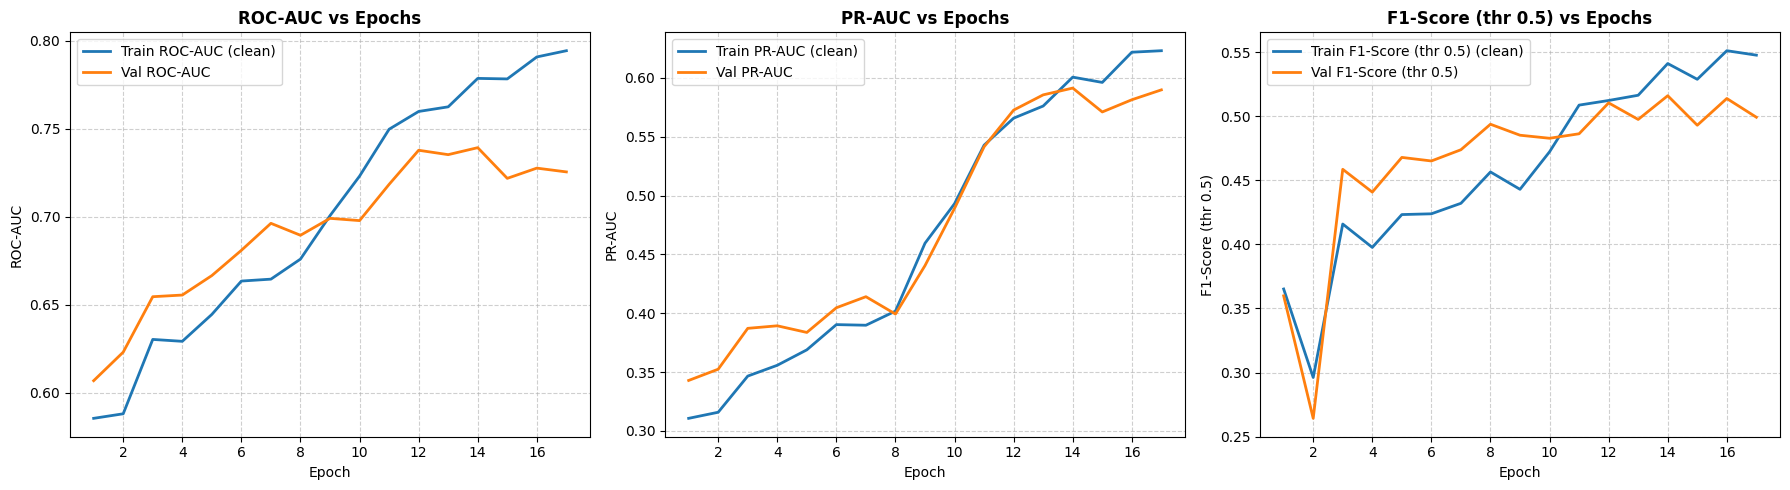

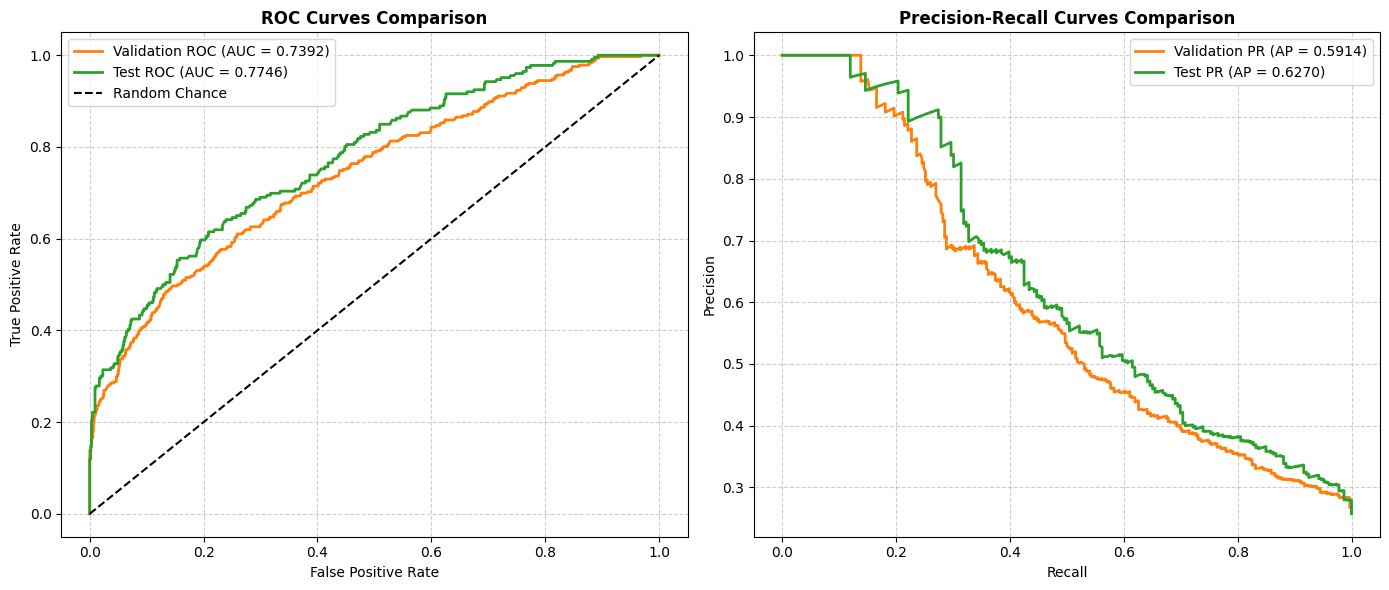

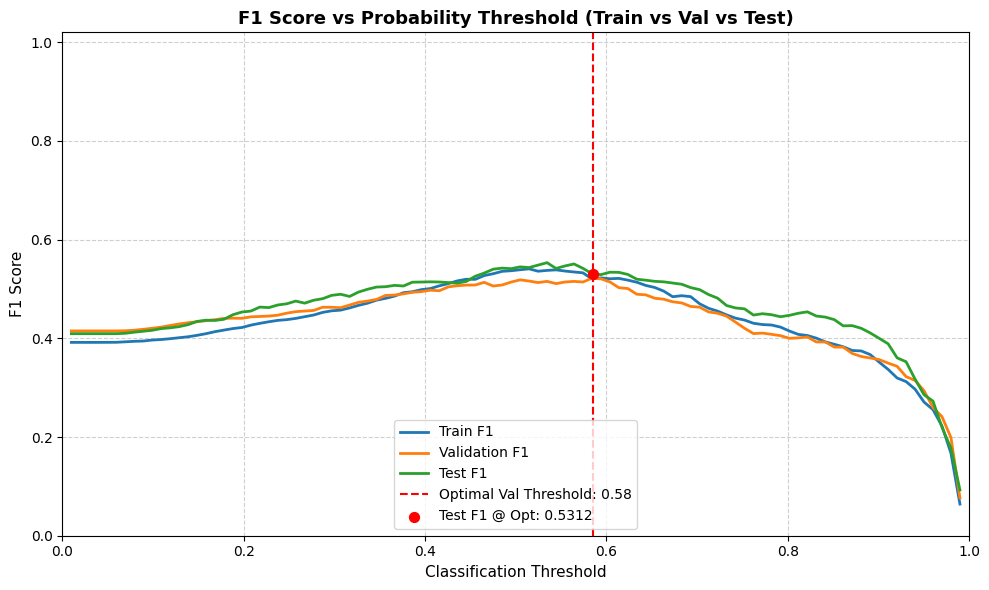

In [1]:
import os, math, random, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomErasing, RandomResizedCrop
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve
)
import rasterio

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
torch.backends.cudnn.benchmark = True

# ==========================================
# CONFIGURATION
# ==========================================
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    OUTPUTDIR     = Path('/kaggle/working')

    TRAINSITE     = ROOT / 'train' / 'site'
    TRAINNOSITE   = ROOT / 'train' / 'no_site'
    VALSITE       = ROOT / 'validation' / 'site'
    VALNOSITE     = ROOT / 'validation' / 'no_site'
    TESTSITE      = ROOT / 'test' / 'site'
    TESTNOSITE    = ROOT / 'test' / 'no_site'

    IMGSUFFIX     = '.tif'
    SATBANDS      = [0, 1, 2, 3]
    LIDARBANDS    = [4, 5, 6, 7, 8, 9, 10]
    INCHANNELS    = len(SATBANDS) + len(LIDARBANDS)

    NUMCLASSES    = 1
    IMGSIZE       = 200          # Changed to 224 to cleanly divide by ConvNeXt's 32x downsampling
    BATCHSIZE     = 32
    NUMEPOCHS     = 40
    BASELR        = 5e-5
    WEIGHTDECAY   = 0.1
    DROPOUT       = 0.6         # Reduced to avoid underfitting with StochDepth
    SEED          = 42
    NUMWORKERS    = 2
    USEAMP        = torch.cuda.is_available()

    # Early stopping & Scheduler
    PATIENCE      = 3
    MINDELTA      = 1e-3
    SCHED_FACTOR  = 0.5
    SCHED_PATIENCE = 2

    # Loss function options
    USEPOSWEIGHT  = False
    USEFOCALLOSS  = False
    FOCALGAMMA    = 2.0
    LABELSMOOTH   = 0.0          # Disabled by default to establish clean baseline

    # Optimizer
    HEADLRMULT    = 5.0
    LLRD          = 0.8         # Flattened from 0.5 to prevent vanishing LR in late stages
    FREEZEEPOCHS  = 8
    FREEZESTAGES  = 4            # Stages 0-3 permanently frozen (stem is exempted)

    # Regularization
    STOCHDEPTH    = 0.3
    MIXUPPROB     = 0.0          # Disabled by default to establish clean baseline
    MIXUPALPHA    = 0.4
    ERASEPROB     = 0.10
    CROPSCALE     = (0.85, 1.0)
    SATNOISESTD   = 0.02
    LIDARNOISESTD = 0.05

    # Stem-inflation / modality dropout
    STEMNOISESTD  = 1e-4
    RGBDROPPROB   = 0.30
    LIDARDROPPROB = 0.15
    SAT_SCALE     = 10000.0      # Global satellite scaling (assuming 16-bit)
    IMAGENET_NORM = True         # Apply ImageNet stats to first 3 channels

    LIDARNORM     = 'global'
    LIDARCLIP     = 8.0
    EVALTRAINEACHEPOCH = True

def setseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setseed(CFG.SEED)
CFG.OUTPUTDIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# DATA LOADING & NORMALIZATION
# ==========================================
def foldertodf(sitedir: Path, nositedir: Path) -> pd.DataFrame:
    rows = [{'filepath': str(f), 'label': l}
            for l, d in [(1, sitedir), (0, nositedir)]
            for f in sorted(d.glob(f'*{CFG.IMGSUFFIX}'))]
    return pd.DataFrame(rows)

print('Scanning dataset folders...')
traindf = foldertodf(CFG.TRAINSITE, CFG.TRAINNOSITE)
valdf   = foldertodf(CFG.VALSITE,   CFG.VALNOSITE)
testdf  = foldertodf(CFG.TESTSITE,  CFG.TESTNOSITE)

def loadrawpatch(tifpath: str):
    with rasterio.open(tifpath) as src:
        # Correctly mask -9999 NoData values and fill with 0.0
        img = src.read(masked=True).astype(np.float32).filled(0.0)

    # Global scaling instead of per-patch
    sat = img[CFG.SATBANDS] / CFG.SAT_SCALE
    sat = np.clip(sat, 0.0, 1.0)
    return sat, img[CFG.LIDARBANDS]

def buildrawcache(df: pd.DataFrame, splitname: str):
    print(f"Caching {len(df)} {splitname} patches into RAM...")
    sats, lidars, labels = [], [], []
    for row in df.itertuples():
        s, l = loadrawpatch(row.filepath)
        sats.append(s); lidars.append(l); labels.append(float(row.label))
    return sats, lidars, labels

def computelidarstats(lidars):
    n = len(CFG.LIDARBANDS)
    total = np.zeros(n, np.float64)
    totalsq = np.zeros(n, np.float64)
    count = 0
    for l in lidars:
        ld = l.astype(np.float64)
        total   += ld.sum(axis=(1, 2))
        totalsq += (ld ** 2).sum(axis=(1, 2))
        count   += l.shape[1] * l.shape[2]
    mean = total / count
    var = np.maximum(totalsq / count - mean ** 2, 1e-12)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)

def normalizelidarperpatch(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr, dtype=np.float32)
    for c, ch in enumerate(arr):
        mean, std = float(np.nanmean(ch)), float(np.nanstd(ch))
        out[c] = ch - mean if std < 1e-4 or np.isnan(std) else (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

def finalizecache(sats, lidars, labels, lmean, lstd):
    out = []
    for i in range(len(sats)):
        l = lidars[i]
        if CFG.LIDARNORM == 'global':
            ln = (l - lmean[:, None, None]) / (lstd[:, None, None] + 1e-6)
            ln = np.clip(ln, -CFG.LIDARCLIP, CFG.LIDARCLIP)
        else:
            ln = normalizelidarperpatch(l)
        ln = np.nan_to_num(ln, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        out.append((np.concatenate([sats[i], ln], axis=0), labels[i]))
        sats[i] = None; lidars[i] = None
    return out

class MultiModalDataset(Dataset):
    def __init__(self, cached, istrain: bool = True):
        self.cached = cached
        self.istrain = istrain
        self.randomerase = RandomErasing(p=CFG.ERASEPROB, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)
        self.randomcrop = RandomResizedCrop(CFG.IMGSIZE, scale=CFG.CROPSCALE, ratio=(0.85, 1.18), antialias=True)
        self.rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.cached)

    def __getitem__(self, idx):
        img, label = self.cached[idx]
        t = torch.from_numpy(img).clone() # Prevent memory mutation
        nsat = len(CFG.SATBANDS)

        if CFG.IMAGENET_NORM and nsat >= 3:
            t[:3] = (t[:3] - self.rgb_mean) / self.rgb_std

        if self.istrain:
            t = self.randomcrop(t)
            if random.random() > 0.5: t = TF.hflip(t)
            if random.random() > 0.5: t = TF.vflip(t)
            k = random.choice([0, 1, 2, 3])
            if k: t = torch.rot90(t, k, dims=(1, 2))

            if random.random() > 0.5:
                t[:nsat] += torch.randn_like(t[:nsat]) * CFG.SATNOISESTD
                t[nsat:] += torch.randn_like(t[nsat:]) * CFG.LIDARNOISESTD

            t = self.randomerase(t)

            if random.random() < CFG.RGBDROPPROB:
                satmean = t[0:nsat].mean(dim=(1, 2), keepdim=True)
                t[0:nsat] = satmean.expand_as(t[0:nsat])
            if random.random() < CFG.LIDARDROPPROB:
                t[nsat:] = 0.0
        else:
            if t.shape[-1] != CFG.IMGSIZE or t.shape[-2] != CFG.IMGSIZE:
                t = TF.resize(t, [CFG.IMGSIZE, CFG.IMGSIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)

        return t, torch.tensor(label, dtype=torch.float32)

trnsats, trnlidars, trnlabels_raw = buildrawcache(traindf, "Train")
LIDARMEAN, LIDARSTD = computelidarstats(trnlidars)
print(f"LiDAR channel means: {np.round(LIDARMEAN, 3)}")
print(f"LiDAR channel stds : {np.round(LIDARSTD, 3)}")

traincache = finalizecache(trnsats, trnlidars, trnlabels_raw, LIDARMEAN, LIDARSTD)
del trnsats, trnlidars; gc.collect()

vs, vl, vlab = buildrawcache(valdf, "Val")
valcache = finalizecache(vs, vl, vlab, LIDARMEAN, LIDARSTD)
del vs, vl; gc.collect()

ts, tl, tlab = buildrawcache(testdf, "Test")
testcache = finalizecache(ts, tl, tlab, LIDARMEAN, LIDARSTD)
del ts, tl; gc.collect()

counts = traindf['label'].value_counts().to_dict()
sampleweights = [1.0 / counts[lbl] for lbl in traindf['label']]
sampler = WeightedRandomSampler(weights=sampleweights, num_samples=len(traindf), replacement=True)

trnloader      = DataLoader(MultiModalDataset(traincache, True), batch_size=CFG.BATCHSIZE, sampler=sampler, num_workers=CFG.NUMWORKERS, pin_memory=True, drop_last=True)
trnloader_eval = DataLoader(MultiModalDataset(traincache, False), batch_size=CFG.BATCHSIZE * 2, shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
valloader      = DataLoader(MultiModalDataset(valcache, False), batch_size=CFG.BATCHSIZE * 2, shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
testloader     = DataLoader(MultiModalDataset(testcache, False), batch_size=CFG.BATCHSIZE * 2, shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

# ==========================================
# MODEL ARCHITECTURE
# ==========================================
def createconvnextmodel(inchannels=11, numclasses=1, dropout=CFG.DROPOUT):
    model = models.convnext_tiny(
        weights=models.ConvNeXt_Tiny_Weights.DEFAULT,
        stochastic_depth_prob=CFG.STOCHDEPTH,
    )

    oldconv = model.features[0][0]
    oldinchannels  = oldconv.weight.shape[1]
    oldoutchannels = oldconv.out_channels

    newconv = nn.Conv2d(
        in_channels=inchannels,
        out_channels=oldoutchannels,
        kernel_size=oldconv.kernel_size,
        stride=oldconv.stride,
        padding=oldconv.padding,
        bias=oldconv.bias is not None,
    )

    with torch.no_grad():
        if inchannels == oldinchannels:
            newconv.weight[:] = oldconv.weight
        elif oldinchannels == 3 and inchannels > 3:
            # Keep the pretrained RGB weights untouched so ImageNet transfer learning
            # is fully preserved; only the newly-added (LiDAR) channels are scaled down
            # so they don't overpower the pretrained RGB variance at initialization.
            newconv.weight[:, 0:3, :, :] = oldconv.weight
            meanweight = oldconv.weight.mean(dim=1)
            for c in range(3, inchannels):
                newconv.weight[:, c, :, :] = meanweight * 0.25
            newconv.weight[:, 3:inchannels, :, :] *= (oldinchannels / inchannels)
            newconv.weight[:, 3:inchannels, :, :] += torch.randn_like(newconv.weight[:, 3:inchannels, :, :]) * CFG.STEMNOISESTD
        else:
            nn.init.kaiming_normal_(newconv.weight, nonlinearity='relu')

        if oldconv.bias is not None:
            newconv.bias.copy_(oldconv.bias)

    model.features[0][0] = newconv
    infeatures = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Dropout(p=dropout),
        nn.Linear(infeatures, numclasses),
    )
    return model

# ==========================================
# REGULARIZATION & LOSS
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        ptcorrect = torch.where(targets >= 0.5, probs, 1 - probs)
        focalterm = (1 - ptcorrect).clamp(min=1e-6).pow(self.gamma)
        loss = focalterm * bce
        if self.pos_weight is not None:
            alphaweight = torch.where(targets >= 0.5, self.pos_weight, torch.ones_like(targets))
            loss = loss * alphaweight
        return loss.mean()

posweighttensor = None
if CFG.USEPOSWEIGHT:
    posweighttensor = torch.tensor([counts.get(0, 0) / max(counts.get(1, 1), 1)], dtype=torch.float32).to(DEVICE)

criterion = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=posweighttensor)
             if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=posweighttensor))

def ishead(name: str) -> bool:
    # Stem conv and stem layernorm are part of the head logic so they stay unfrozen
    return name.startswith('features.0.0') or name.startswith('features.0.1') or name.startswith('classifier')

def stagedepth(name: str) -> int:
    if name.startswith('classifier'): return 8
    if name.startswith('features.'): return int(name.split('.')[1])
    return 0

def freezeearlystages(model, upto: int):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True 
            continue
        if name.startswith('features.'):
            if int(name.split('.')[1]) < upto:
                p.requires_grad = False

def setbackbonefrozen(model, frozen: bool):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True  
            continue
        if name.startswith('features.'):
            stage = int(name.split('.')[1])
            if stage < CFG.FREEZESTAGES:
                continue
        p.requires_grad = not frozen

def buildparamgroups(model, baselr, weightdecay, headlrmult, llrd):
    maxdepth = 8
    buckets = {}
    for name, p in model.named_parameters():
        lr = baselr * headlrmult if ishead(name) else baselr * (llrd ** (maxdepth - stagedepth(name)))
        # Do not decay layer_scale or norm
        wd = 0.0 if (p.ndim <= 1 or 'norm' in name.lower() or 'layer_scale' in name.lower()) else weightdecay
        buckets.setdefault((round(lr, 12), wd), []).append((name, p))

    groups = []
    for (lr, wd), items in sorted(buckets.items()):
        groups.append({'params': [p for _, p in items], 'lr': lr, 'weight_decay': wd})
    return groups

model = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
# Note: freezeearlystages is called first to permanently freeze stages < FREEZESTAGES,
# then setbackbonefrozen freezes the rest of the backbone for the initial warm-up phase.
# setbackbonefrozen intentionally leaves stages < FREEZESTAGES untouched (via `continue`)
# because freezeearlystages has already frozen them; do not call setbackbonefrozen alone
# without freezeearlystages having run first, or those stages would remain trainable.
freezeearlystages(model, CFG.FREEZESTAGES)
setbackbonefrozen(model, frozen=True)

optimizer = optim.AdamW(buildparamgroups(model, CFG.BASELR, CFG.WEIGHTDECAY, CFG.HEADLRMULT, CFG.LLRD))
# Swapped to ReduceLROnPlateau 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.SCHED_FACTOR, patience=CFG.SCHED_PATIENCE, min_lr=1e-6)
scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)
backbonefrozen = True

# ==========================================
# TRAINING PIPELINE
# ==========================================
bestvalauc = 0.0
epochsnoimprove = 0
ckptpath = CFG.OUTPUTDIR / 'convnext_tiny_multimodal_best.pth'

history = {'epoch': [], 'trn_loss': [], 'val_loss': [], 'trn_roc_auc': [], 'val_roc_auc': [], 'trn_pr_auc': [], 'val_pr_auc': [], 'trn_f1': [], 'val_f1': []}

def computemetrics(ytrue, ypred):
    auc   = roc_auc_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    prauc = average_precision_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    binpreds = [1 if p >= 0.5 else 0 for p in ypred]
    return (auc, prauc, precision_score(ytrue, binpreds, zero_division=0), recall_score(ytrue, binpreds, zero_division=0), f1_score(ytrue, binpreds, zero_division=0), accuracy_score(ytrue, binpreds))

def trainepoch(model, loader, optimizer, scaler):
    model.train()
    totalloss, seen = 0.0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        target = (labels * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH if CFG.LABELSMOOTH > 0 else labels)

        if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
            lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
            perm = torch.randperm(inputs.size(0), device=DEVICE)
            inputs = lam * inputs + (1 - lam) * inputs[perm]
            target = lam * target + (1 - lam) * target[perm]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
    return totalloss / max(seen, 1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    totalloss, seen, alllabels, allpreds = 0.0, 0, [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, labels)
        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
        allpreds.extend(np.nan_to_num(torch.sigmoid(logits).float().cpu().numpy(), nan=0.5))
        alllabels.extend(labels.cpu().numpy())
    return (totalloss / max(seen, 1), *computemetrics(alllabels, allpreds), alllabels, allpreds)

print(f'\n{"="*78}\n  ConvNeXt-Tiny | 11-channel multimodal | max {CFG.NUMEPOCHS} epochs, patience {CFG.PATIENCE}\n{"="*78}')

for epoch in range(1, CFG.NUMEPOCHS + 1):
    if backbonefrozen and epoch > CFG.FREEZEEPOCHS:
        setbackbonefrozen(model, frozen=False)
        backbonefrozen = False
        epochsnoimprove = 0
        print(f'  -> Unfroze backbone at epoch {epoch}')

    trnloss = trainepoch(model, trnloader, optimizer, scaler)
    valloss, valauc, valprauc, valprec, valrec, valf1, valacc, _, _ = evaluate(model, valloader)

    # Only let the plateau scheduler act once the backbone is actually training;
    # during the frozen warm-up phase (head/stem only) val AUC can plateau for
    # reasons unrelated to backbone LR, which would otherwise trigger a premature
    # decay before the backbone even gets a chance to train at the base LR.
    if not backbonefrozen:
        scheduler.step(valauc)

    if CFG.EVALTRAINEACHEPOCH:
        ctrnloss, trnauc, trnprauc, _, _, trnf1, _, _, _ = evaluate(model, trnloader_eval)
    else:
        ctrnloss, trnauc, trnprauc, trnf1 = trnloss, 0.0, 0.0, 0.0

    history['epoch'].append(epoch)
    history['trn_loss'].append(ctrnloss)
    history['val_loss'].append(valloss)
    history['trn_roc_auc'].append(trnauc)
    history['val_roc_auc'].append(valauc)
    history['trn_pr_auc'].append(trnprauc)
    history['val_pr_auc'].append(valprauc)
    history['trn_f1'].append(trnf1)
    history['val_f1'].append(valf1)

    saved = ''
    if valauc > bestvalauc + CFG.MINDELTA:
        bestvalauc = valauc
        epochsnoimprove = 0
        torch.save(model.state_dict(), ckptpath)
        saved = '  ✓ saved'
    else:
        # Crucial fix: Only increment patience if the backbone is unfrozen
        if not backbonefrozen:
            epochsnoimprove += 1

    headlr = max(g['lr'] for g in optimizer.param_groups)
    print(f'Ep {epoch:02d}/{CFG.NUMEPOCHS} | head LR: {headlr:.2e} | '
          f'clean AUC gap: {trnauc - valauc:+.4f} | patience: {epochsnoimprove}/{CFG.PATIENCE}{saved}')
    print(f'  Train (aug)   -> Loss: {trnloss:.4f}')
    print(f'  Train (clean) -> Loss: {ctrnloss:.4f} | ROC-AUC: {trnauc:.4f} | PR-AUC: {trnprauc:.4f} | F1: {trnf1:.4f}')
    print(f'  Val           -> Loss: {valloss:.4f} | ROC-AUC: {valauc:.4f} | PR-AUC: {valprauc:.4f} | F1: {valf1:.4f}')

    # Crucial fix: Prevent early stopping during the frozen epochs
    if not backbonefrozen and epochsnoimprove >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}: val ROC-AUC flat for {CFG.PATIENCE} epochs.')
        break

# ==========================================
# TEST SET BENCHMARK & THRESHOLD CALIBRATION
# ==========================================
if ckptpath.exists() and bestvalauc > 0.0:
    model.load_state_dict(torch.load(ckptpath, map_location=DEVICE, weights_only=True))
    model.eval()

    _, _, _, _, _, _, _, trnlabels, trnpreds  = evaluate(model, trnloader_eval)
    _, _, _, _, _, _, _, vallabels, valpreds  = evaluate(model, valloader)
    _, tstauc, tstprauc, _, _, _, _, testlabels, testpreds = evaluate(model, testloader)

    valprauc_best = average_precision_score(vallabels, valpreds)
    valprecisions, valrecalls, valthresholds = precision_recall_curve(vallabels, valpreds)
    f1_scores = 2 * (valprecisions[:-1] * valrecalls[:-1]) / (valprecisions[:-1] + valrecalls[:-1] + 1e-8)
    bestthresh = float(valthresholds[np.argmax(f1_scores)])

    testpredsnp, testlabelsnp = np.array(testpreds), np.array(testlabels)
    bindefault = (testpredsnp >= 0.5).astype(int)
    binopt     = (testpredsnp >= bestthresh).astype(int)

    print("\n" + "=" * 68 + "\n      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)\n" + "=" * 68)
    print(f"Threshold-free   -> ROC-AUC: {tstauc:.4f} | PR-AUC: {tstprauc:.4f}")
    print(f"Optimal threshold calibrated on val: {bestthresh:.4f}")

    for tag, binp in [("Default (0.50)", bindefault), (f"Calibrated ({bestthresh:.4f})", binopt)]:
        print(f"\nTest @ {tag}:")
        print(f"  • Precision : {precision_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Recall    : {recall_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • F1-Score  : {f1_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Accuracy  : {accuracy_score(testlabelsnp, binp):.4f}")
    print("=" * 68)

    # ==========================================
    # METRIC PLOTS
    # ==========================================
    epochs = history['epoch']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (trnkey, valkey, name) in zip(axes, [
        ('trn_roc_auc', 'val_roc_auc', 'ROC-AUC'),
        ('trn_pr_auc',  'val_pr_auc',  'PR-AUC'),
        ('trn_f1',      'val_f1',      'F1-Score (thr 0.5)'),
    ]):
        ax.plot(epochs, history[trnkey], label=f'Train {name} (clean)', color='tab:blue', lw=2)
        ax.plot(epochs, history[valkey], label=f'Val {name}', color='tab:orange', lw=2)
        ax.set_title(f'{name} vs Epochs', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(name)
        ax.grid(True, linestyle='--', alpha=0.6); ax.legend()
    plt.tight_layout()
    plt.savefig(CFG.OUTPUTDIR / 'metrics_progression.png', dpi=300)
    plt.show()

    val_fpr, val_tpr, _ = roc_curve(vallabels, valpreds)
    tst_fpr, tst_tpr, _ = roc_curve(testlabels, testpreds)
    val_prec_c, val_rec_c, _ = precision_recall_curve(vallabels, valpreds)
    tst_prec_c, tst_rec_c, _ = precision_recall_curve(testlabels, testpreds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].plot(val_fpr, val_tpr, label=f'Validation ROC (AUC = {bestvalauc:.4f})', color='tab:orange', lw=2)
    axes[0].plot(tst_fpr, tst_tpr, label=f'Test ROC (AUC = {tstauc:.4f})', color='tab:green', lw=2)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
    axes[0].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].grid(True, linestyle='--', alpha=0.6); axes[0].legend()

    axes[1].plot(val_rec_c, val_prec_c, label=f'Validation PR (AP = {valprauc_best:.4f})', color='tab:orange', lw=2)
    axes[1].plot(tst_rec_c, tst_prec_c, label=f'Test PR (AP = {tstprauc:.4f})', color='tab:green', lw=2)
    axes[1].set_title('Precision-Recall Curves Comparison', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].grid(True, linestyle='--', alpha=0.6); axes[1].legend()

    plt.tight_layout()
    plt.savefig(CFG.OUTPUTDIR / 'roc_pr_curves_comparison.png', dpi=300)
    plt.show()

    thresh_range = np.linspace(0.01, 0.99, 100)
    trnpredsnp, valpredsnp = np.array(trnpreds), np.array(valpreds)
    trn_f1_curve = [f1_score(trnlabels,  (trnpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
    val_f1_curve = [f1_score(vallabels,  (valpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
    tst_f1_curve = [f1_score(testlabels, (testpredsnp >= t).astype(int), zero_division=0) for t in thresh_range]

    plt.figure(figsize=(10, 6))
    plt.plot(thresh_range, trn_f1_curve, label='Train F1', color='tab:blue', lw=2)
    plt.plot(thresh_range, val_f1_curve, label='Validation F1', color='tab:orange', lw=2)
    plt.plot(thresh_range, tst_f1_curve, label='Test F1', color='tab:green', lw=2)
    plt.axvline(x=bestthresh, color='red', linestyle='--', lw=1.5, label=f'Optimal Val Threshold: {bestthresh:.2f}')
    test_f1_at_opt = f1_score(testlabelsnp, binopt, zero_division=0)
    plt.scatter([bestthresh], [test_f1_at_opt], color='red', s=50, zorder=5, label=f'Test F1 @ Opt: {test_f1_at_opt:.4f}')
    plt.title('F1 Score vs Probability Threshold (Train vs Val vs Test)', fontsize=13, fontweight='bold')
    plt.xlabel('Classification Threshold', fontsize=11); plt.ylabel('F1 Score', fontsize=11)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
    plt.grid(True, linestyle='--', alpha=0.6); plt.legend(loc='lower center', fontsize=10)
    plt.tight_layout()
    plt.savefig(CFG.OUTPUTDIR / '3in1_f1_threshold_curve.png', dpi=300)
    plt.show()

gc.collect()
torch.cuda.empty_cache()